In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

from DiFD.datasets.injected import InjectedDataset
from DiFD.schema import FaultType


In [2]:
# Load the injected dataset
data_path = "../data/injected/injected_dataset.npz"
dataset = InjectedDataset.load(data_path)

# Display summary
dataset.print_summary()


  Injected Dataset Summary  
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Array   ┃ Shape          ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ X_train │ (25213, 60, 4) │
│ y_train │ (25213, 60)    │
│ X_test  │ (1027, 60, 4)  │
│ y_test  │ (1027, 60)     │
└─────────┴────────────────┘

Features: ['temp', 'humid', 'light', 'volt']

Class Distribution (Train):

┏━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Fault Type ┃     Count ┃ Percentage ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ NORMAL     │ 1,351,034 │     89.31% │
│ SPIKE      │    52,709 │      3.48% │
│ DRIFT      │    56,269 │      3.72% │
│ STUCK      │    52,768 │      3.49% │
└────────────┴───────────┴────────────┘

Class Distribution (Test):

┏━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Fault Type ┃  Count ┃ Percentage ┃
┡━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ NORMAL     │ 55,824 │     90.59% │
│ SPIKE      │  2,198 │      3.57% │
│ DRIFT      │  1,669 │      2.71% │
│ STUCK      │  1,929 │      3.13% │
└────────────┴────────┴────────────┘

In [3]:
print(f"X_train shape: {dataset.X_train.shape} (samples, window_size, features)")
print(f"y_train shape: {dataset.y_train.shape} (samples, window_size)")
print(f"X_test shape: {dataset.X_test.shape}")
print(f"y_test shape: {dataset.y_test.shape}")
print(f"\nFeatures: {dataset.feature_names}")
print(f"\nFault types: {[ft.name for ft in FaultType]}")


X_train shape: (25213, 60, 4) (samples, window_size, features)
y_train shape: (25213, 60) (samples, window_size)
X_test shape: (1027, 60, 4)
y_test shape: (1027, 60)

Features: ['temp', 'humid', 'light', 'volt']

Fault types: ['NORMAL', 'SPIKE', 'DRIFT', 'STUCK']


In [4]:
def find_fault_transitions(y: np.ndarray) -> dict[str, list[tuple[int, int]]]:
    """Find windows and timesteps where fault transitions occur.
    
    Returns:
        Dict mapping fault type name to list of (window_idx, transition_timestep)
    """
    transitions = {ft.name: [] for ft in FaultType if ft != FaultType.NORMAL}
    
    for window_idx in range(y.shape[0]):
        window_labels = y[window_idx]
        for t in range(1, len(window_labels)):
            prev_state = window_labels[t-1]
            curr_state = window_labels[t]
            if prev_state == FaultType.NORMAL.value and curr_state != FaultType.NORMAL.value:
                fault_name = FaultType(curr_state).name
                transitions[fault_name].append((window_idx, t))
    
    return transitions

train_transitions = find_fault_transitions(dataset.y_train)
test_transitions = find_fault_transitions(dataset.y_test)

print("Fault Transitions Found (Train):")
for fault_type, trans_list in train_transitions.items():
    print(f"  {fault_type}: {len(trans_list)} transitions")

print("\nFault Transitions Found (Test):")
for fault_type, trans_list in test_transitions.items():
    print(f"  {fault_type}: {len(trans_list)} transitions")


Fault Transitions Found (Train):
  SPIKE: 26046 transitions
  DRIFT: 1329 transitions
  STUCK: 3509 transitions

Fault Transitions Found (Test):
  SPIKE: 1084 transitions
  DRIFT: 46 transitions
  STUCK: 129 transitions


In [5]:
FAULT_COLORS = {
    FaultType.NORMAL.value: '#2ecc71',
    FaultType.SPIKE.value: '#e74c3c',
    FaultType.DRIFT.value: '#f39c12',
    FaultType.STUCK.value: '#9b59b6'
}

def plot_prefault_postfault_comparison(
    X: np.ndarray,
    y: np.ndarray,
    window_idx: int,
    feature_idx: int,
    feature_names: list[str],
    transition_timestep: int,
    context_before: int = 10,
    context_after: int = 20,
):
    """Plot side-by-side comparison of pre-fault and post-fault data."""
    window_data = X[window_idx, :, feature_idx]
    window_labels = y[window_idx]
    feature_name = feature_names[feature_idx]
    
    transition_idx = transition_timestep
    fault_type_name = FaultType(window_labels[transition_idx]).name
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Plot 1: Pre-fault region (NORMAL data)
    start_pre = max(0, transition_idx - context_before)
    pre_data = window_data[start_pre:transition_idx]
    pre_labels = window_labels[start_pre:transition_idx]
    time_pre = np.arange(start_pre, transition_idx)
    
    axes[0].plot(time_pre, pre_data, 'b-', linewidth=1.5, label='Signal')
    axes[0].scatter(time_pre, pre_data, c=[FAULT_COLORS[l] for l in pre_labels], s=30, zorder=5)
    axes[0].axvline(x=transition_idx, color='red', linestyle='--', alpha=0.7, label='Fault Start')
    axes[0].set_title(f"Pre-Fault (NORMAL)\n{len(pre_data)} timesteps before transition")
    axes[0].set_xlabel("Timestep")
    axes[0].set_ylabel(feature_name)
    axes[0].legend(loc='best', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Post-fault region
    end_post = min(len(window_data), transition_idx + context_after)
    post_data = window_data[transition_idx:end_post]
    post_labels = window_labels[transition_idx:end_post]
    time_post = np.arange(transition_idx, end_post)
    
    axes[1].plot(time_post, post_data, 'b-', linewidth=1.5, label='Signal')
    axes[1].scatter(time_post, post_data, c=[FAULT_COLORS[l] for l in post_labels], s=30, zorder=5)
    axes[1].axvline(x=transition_idx, color='red', linestyle='--', alpha=0.7, label='Fault Start')
    axes[1].set_title(f"Post-Fault ({fault_type_name})\n{len(post_data)} timesteps after transition")
    axes[1].set_xlabel("Timestep")
    axes[1].set_ylabel(feature_name)
    axes[1].legend(loc='best', fontsize=8)
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Full window with transition highlighted
    axes[2].plot(window_data, 'b-', linewidth=1, alpha=0.7, label='Signal')
    for t in range(len(window_labels)):
        axes[2].axvspan(t, t+1, alpha=0.2, color=FAULT_COLORS[window_labels[t]])
    axes[2].axvline(x=transition_idx, color='red', linestyle='--', linewidth=2, label='Fault Start')
    axes[2].set_title(f"Full Window (idx={window_idx})")
    axes[2].set_xlabel("Timestep")
    axes[2].set_ylabel(feature_name)
    legend_elements = [Patch(facecolor=FAULT_COLORS[ft.value], alpha=0.5, label=ft.name) for ft in FaultType]
    axes[2].legend(handles=legend_elements, loc='upper right', fontsize=8)
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle(f"Feature: {feature_name} | Window: {window_idx} | Transition at t={transition_idx}", 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nStatistics for {feature_name}:")
    print(f"  Pre-fault mean:  {np.mean(pre_data):.4f}, std: {np.std(pre_data):.4f}")
    print(f"  Post-fault mean: {np.mean(post_data):.4f}, std: {np.std(post_data):.4f}")
    print(f"  Mean difference: {np.mean(post_data) - np.mean(pre_data):.4f}")



SPIKE Example 1: Window 0, Transition at timestep 52


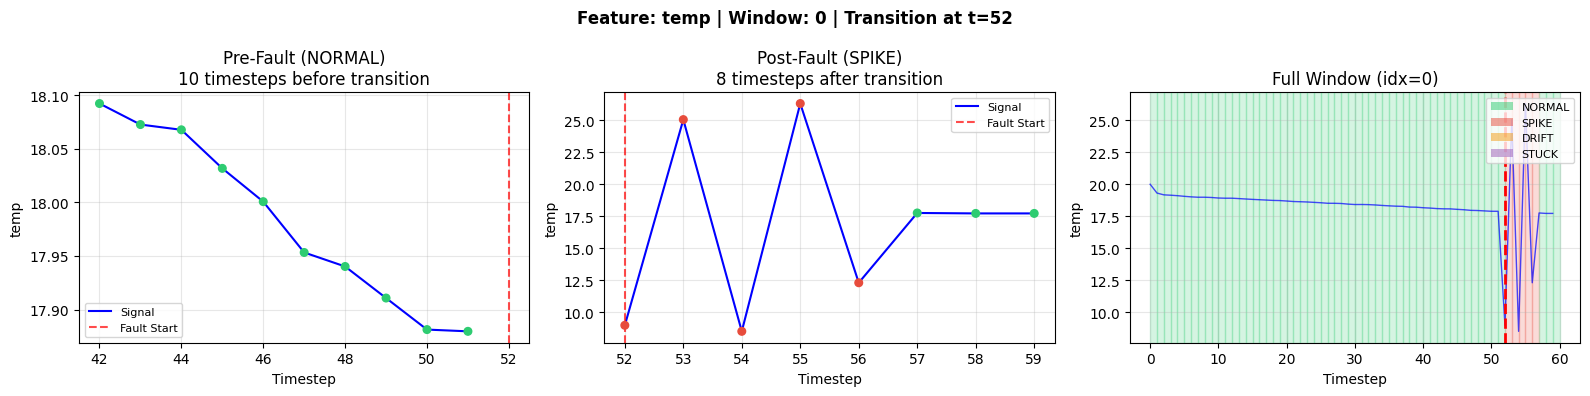


Statistics for temp:
  Pre-fault mean:  17.9830, std: 0.0766
  Post-fault mean: 16.7883, std: 6.2265
  Mean difference: -1.1946

SPIKE Example 2: Window 1, Transition at timestep 42


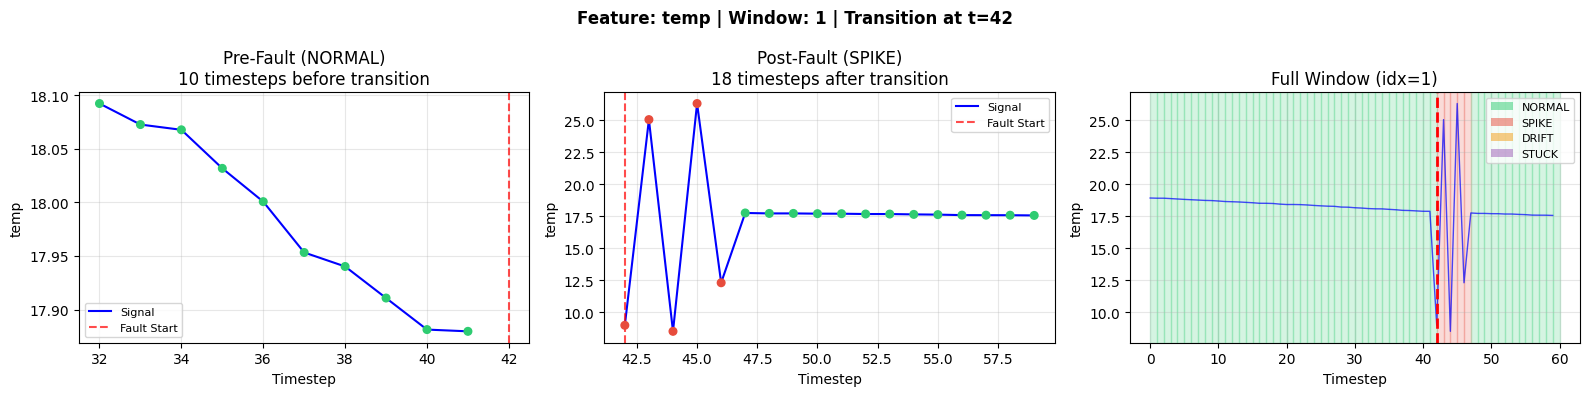


Statistics for temp:
  Pre-fault mean:  17.9830, std: 0.0766
  Post-fault mean: 17.2544, std: 4.1720
  Mean difference: -0.7286

SPIKE Example 3: Window 2, Transition at timestep 32


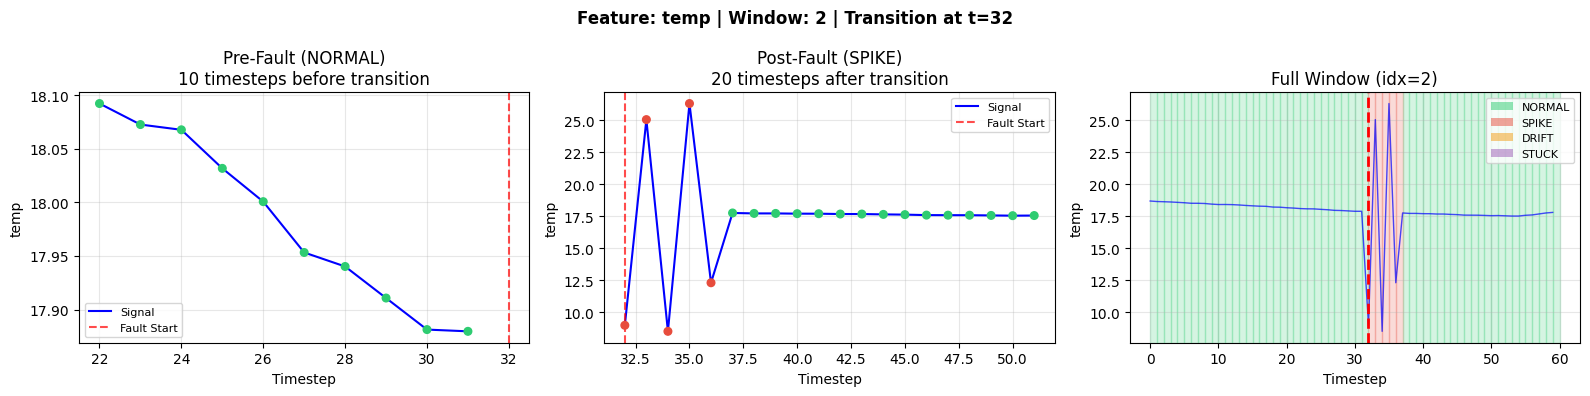


Statistics for temp:
  Pre-fault mean:  17.9830, std: 0.0766
  Post-fault mean: 17.2833, std: 3.9589
  Mean difference: -0.6997


In [6]:
# Analyze SPIKE fault transitions
spike_transitions = train_transitions.get('SPIKE', [])
if spike_transitions:
    for i, (window_idx, trans_t) in enumerate(spike_transitions[:3]):
        print(f"\n{'='*60}")
        print(f"SPIKE Example {i+1}: Window {window_idx}, Transition at timestep {trans_t}")
        print(f"{'='*60}")
        plot_prefault_postfault_comparison(
            dataset.X_train, dataset.y_train, window_idx, 0, dataset.feature_names, trans_t
        )
else:
    print("No SPIKE transitions found in training set.")



DRIFT Example 1: Window 282, Transition at timestep 53


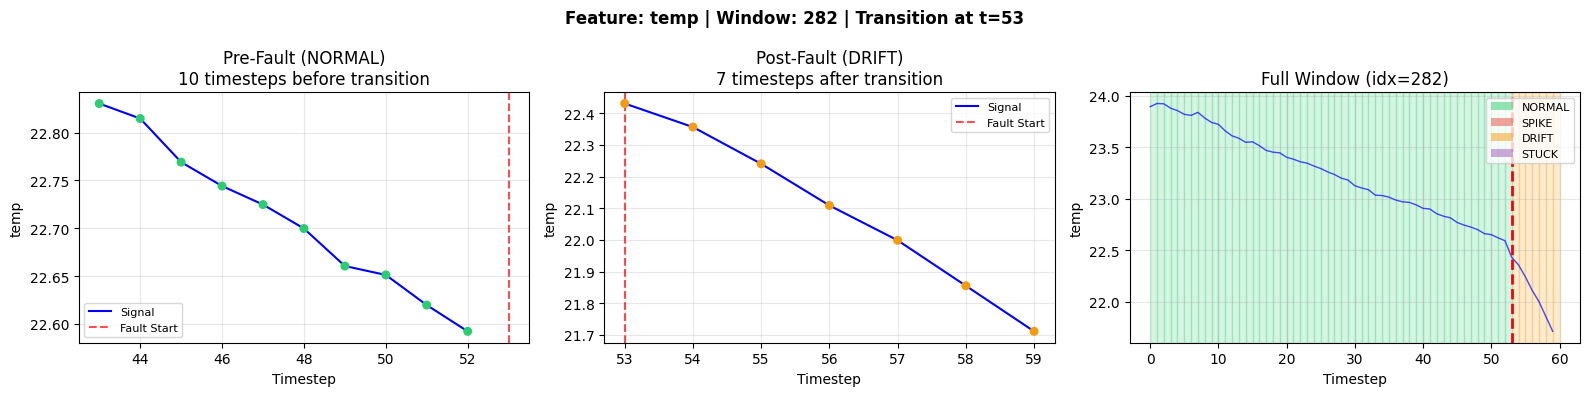


Statistics for temp:
  Pre-fault mean:  22.7107, std: 0.0764
  Post-fault mean: 22.1000, std: 0.2436
  Mean difference: -0.6106

DRIFT Example 2: Window 283, Transition at timestep 43


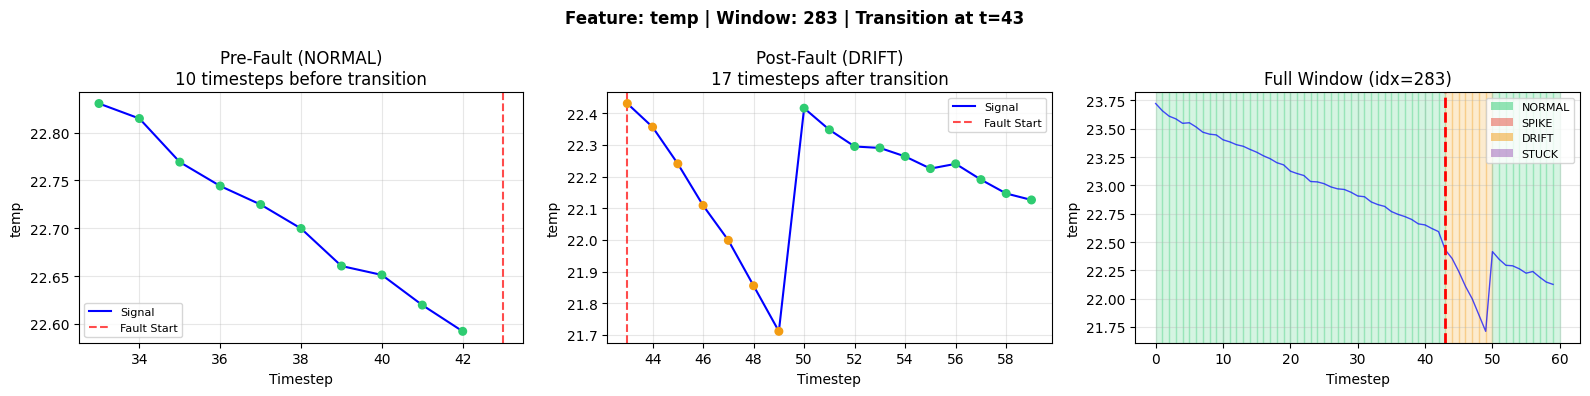


Statistics for temp:
  Pre-fault mean:  22.7107, std: 0.0764
  Post-fault mean: 22.1905, std: 0.1853
  Mean difference: -0.5202

DRIFT Example 3: Window 284, Transition at timestep 33


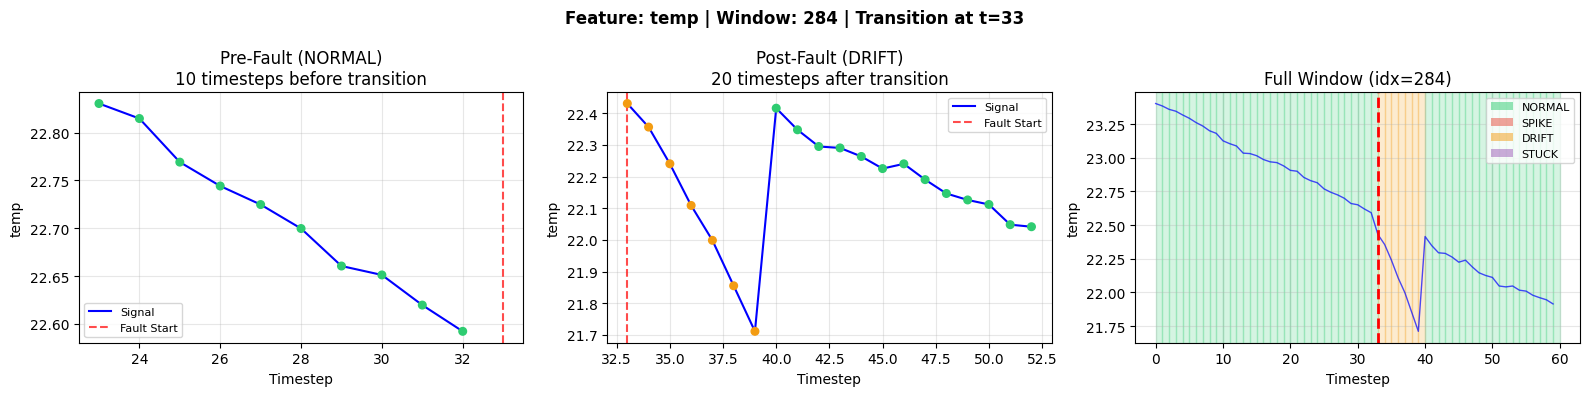


Statistics for temp:
  Pre-fault mean:  22.7107, std: 0.0764
  Post-fault mean: 22.1720, std: 0.1769
  Mean difference: -0.5387


In [7]:
# Analyze DRIFT fault transitions
drift_transitions = train_transitions.get('DRIFT', [])
if drift_transitions:
    for i, (window_idx, trans_t) in enumerate(drift_transitions[:3]):
        print(f"\n{'='*60}")
        print(f"DRIFT Example {i+1}: Window {window_idx}, Transition at timestep {trans_t}")
        print(f"{'='*60}")
        plot_prefault_postfault_comparison(
            dataset.X_train, dataset.y_train, window_idx, 0, dataset.feature_names, trans_t
        )
else:
    print("No DRIFT transitions found in training set.")



STUCK Example 1: Window 3, Transition at timestep 55


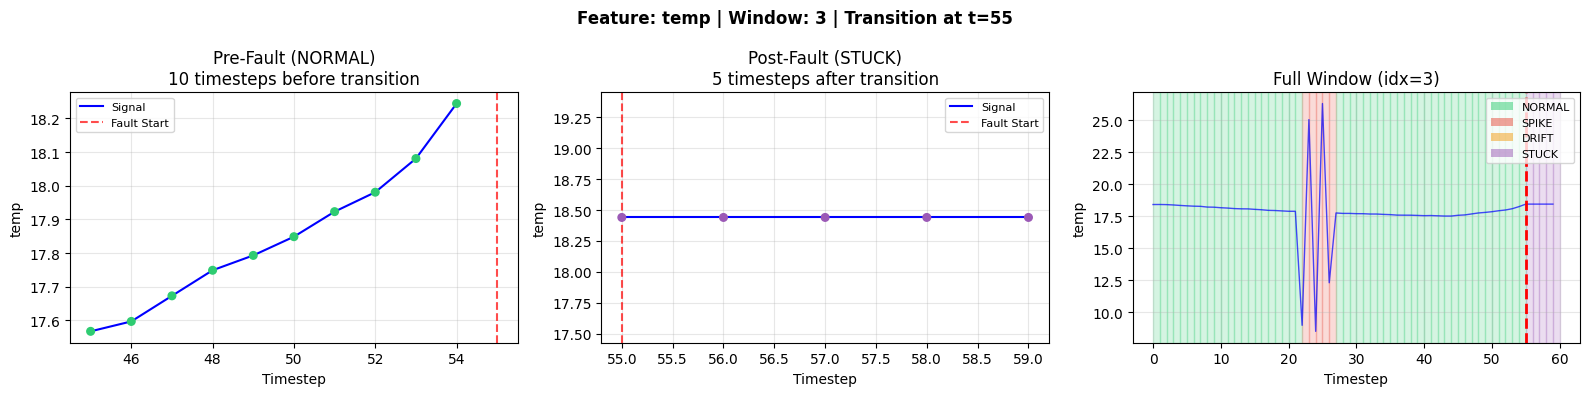


Statistics for temp:
  Pre-fault mean:  17.8458, std: 0.2047
  Post-fault mean: 18.4400, std: 0.0000
  Mean difference: 0.5942

STUCK Example 2: Window 4, Transition at timestep 45


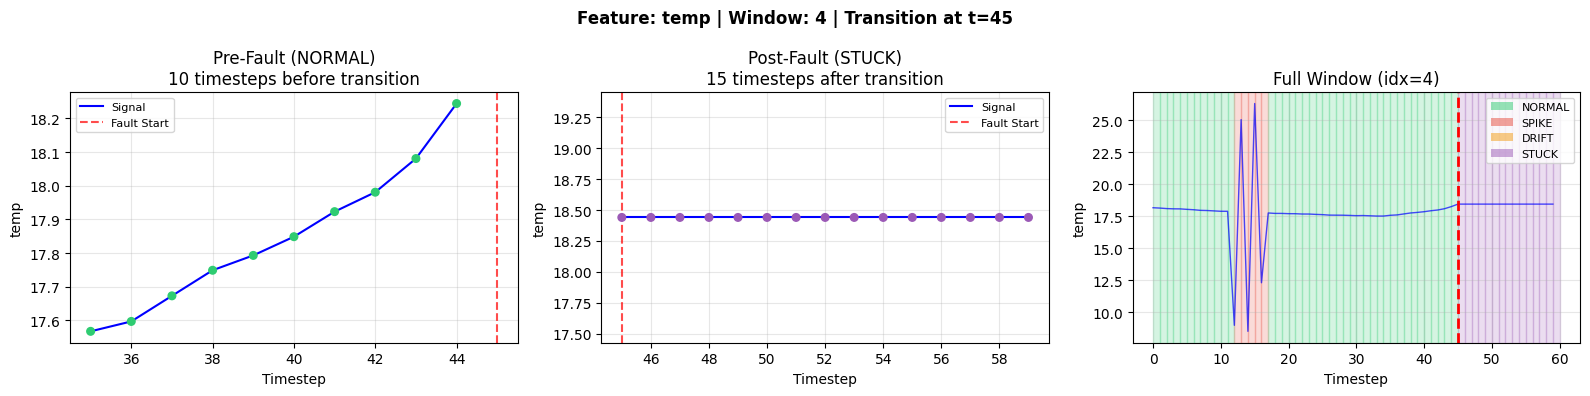


Statistics for temp:
  Pre-fault mean:  17.8458, std: 0.2047
  Post-fault mean: 18.4400, std: 0.0000
  Mean difference: 0.5942

STUCK Example 3: Window 5, Transition at timestep 35


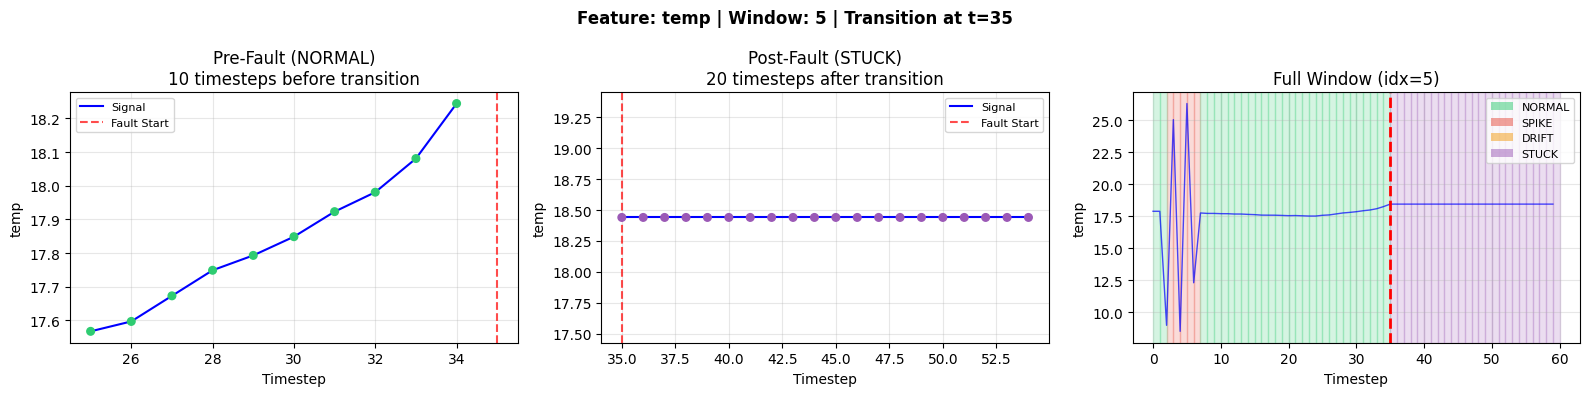


Statistics for temp:
  Pre-fault mean:  17.8458, std: 0.2047
  Post-fault mean: 18.4400, std: 0.0000
  Mean difference: 0.5942


In [8]:
# Analyze STUCK fault transitions
stuck_transitions = train_transitions.get('STUCK', [])
if stuck_transitions:
    for i, (window_idx, trans_t) in enumerate(stuck_transitions[:3]):
        print(f"\n{'='*60}")
        print(f"STUCK Example {i+1}: Window {window_idx}, Transition at timestep {trans_t}")
        print(f"{'='*60}")
        plot_prefault_postfault_comparison(
            dataset.X_train, dataset.y_train, window_idx, 0, dataset.feature_names, trans_t
        )
else:
    print("No STUCK transitions found in training set.")


In [9]:
def compute_prefault_postfault_stats(
    X: np.ndarray,
    y: np.ndarray,
    transitions: dict[str, list[tuple[int, int]]],
    feature_names: list[str],
    context_size: int = 10
) -> pd.DataFrame:
    """Compute aggregate statistics for pre-fault vs post-fault regions."""
    results = []
    
    for fault_type, trans_list in transitions.items():
        if not trans_list:
            continue
            
        for feat_idx, feat_name in enumerate(feature_names):
            pre_values = []
            post_values = []
            
            for window_idx, trans_t in trans_list:
                window_data = X[window_idx, :, feat_idx]
                
                start_pre = max(0, trans_t - context_size)
                pre_values.extend(window_data[start_pre:trans_t])
                
                end_post = min(len(window_data), trans_t + context_size)
                post_values.extend(window_data[trans_t:end_post])
            
            if pre_values and post_values:
                pre_arr = np.array(pre_values)
                post_arr = np.array(post_values)
                
                results.append({
                    "Fault Type": fault_type,
                    "Feature": feat_name,
                    "Pre-Fault Mean": np.mean(pre_arr),
                    "Pre-Fault Std": np.std(pre_arr),
                    "Post-Fault Mean": np.mean(post_arr),
                    "Post-Fault Std": np.std(post_arr),
                    "Mean Diff": np.mean(post_arr) - np.mean(pre_arr),
                    "Std Ratio": np.std(post_arr) / np.std(pre_arr) if np.std(pre_arr) > 0 else np.nan,
                    "N Transitions": len(trans_list)
                })
    
    return pd.DataFrame(results)

stats_df = compute_prefault_postfault_stats(
    dataset.X_train, dataset.y_train, train_transitions, dataset.feature_names
)

if not stats_df.empty:
    print("Pre-Fault vs Post-Fault Statistics (Training Set):")
    display(stats_df.round(4))
else:
    print("No transitions found for statistical comparison.")


Pre-Fault vs Post-Fault Statistics (Training Set):


,Fault Type,Feature,Pre-Fault Mean,Pre-Fault Std,Post-Fault Mean,Post-Fault Std,Mean Diff,Std Ratio,N Transitions
0,SPIKE,temp,22.301001,3.531700,22.331900,4.927500,0.0309,1.3952,26046
1,SPIKE,humid,37.926498,6.377200,37.907398,6.395600,-0.0191,1.0029,26046
2,SPIKE,light,465.430603,569.054382,464.485199,567.455200,-0.9455,0.9972,26046
3,SPIKE,volt,2.609500,0.100200,2.609400,0.100500,-0.0000,1.0034,26046
4,DRIFT,temp,22.421900,3.904600,22.387699,3.429100,-0.0342,0.8782,1329
5,DRIFT,humid,37.677601,6.725700,37.632500,6.659800,-0.0451,0.9902,1329
6,DRIFT,light,413.852203,508.963806,415.902008,503.501404,2.0499,0.9893,1329
7,DRIFT,volt,2.611000,0.098700,2.611800,0.098800,0.0008,1.0011,1329
8,STUCK,temp,22.231701,3.718100,22.198500,3.530200,-0.0332,0.9495,3509
9,STUCK,humid,38.015400,6.650300,38.126900,6.716600,0.1115,1.0100,3509


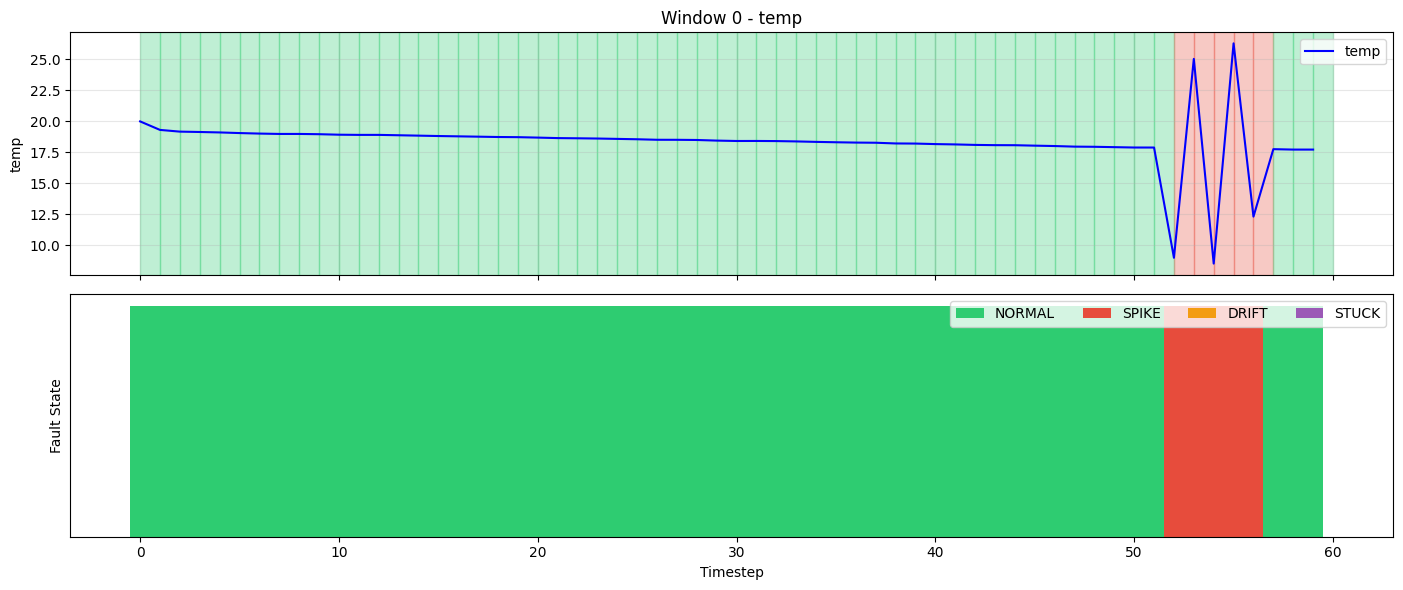


Label distribution in window 0:
  NORMAL: 55 timesteps (91.7%)
  SPIKE: 5 timesteps (8.3%)


In [10]:
def explore_window(
    X: np.ndarray,
    y: np.ndarray,
    window_idx: int,
    feature_names: list[str],
    feature_idx: int = 0
):
    """Explore a specific window with detailed visualization."""
    window_data = X[window_idx, :, feature_idx]
    window_labels = y[window_idx]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    
    # Top: Signal with colored background
    ax1.plot(window_data, 'b-', linewidth=1.5, label=feature_names[feature_idx])
    for t in range(len(window_labels)):
        ax1.axvspan(t, t+1, alpha=0.3, color=FAULT_COLORS[window_labels[t]])
    ax1.set_ylabel(feature_names[feature_idx])
    ax1.set_title(f"Window {window_idx} - {feature_names[feature_idx]}")
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')
    
    # Bottom: Label timeline
    label_colors = [FAULT_COLORS[l] for l in window_labels]
    ax2.bar(range(len(window_labels)), [1]*len(window_labels), color=label_colors, width=1.0, edgecolor='none')
    ax2.set_ylabel("Fault State")
    ax2.set_xlabel("Timestep")
    ax2.set_yticks([])
    legend_elements = [Patch(facecolor=FAULT_COLORS[ft.value], label=ft.name) for ft in FaultType]
    ax2.legend(handles=legend_elements, loc='upper right', ncol=4)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nLabel distribution in window {window_idx}:")
    for ft in FaultType:
        count = np.sum(window_labels == ft.value)
        if count > 0:
            print(f"  {ft.name}: {count} timesteps ({100*count/len(window_labels):.1f}%)")

# Explore a window - change window_idx to explore different windows
window_idx = 0
feature_idx = 0
explore_window(dataset.X_train, dataset.y_train, window_idx, dataset.feature_names, feature_idx)


In [11]:
# Display the injection configuration used
print("Injection Configuration:")
print(f"  Seed: {dataset.config.seed}")
print(f"  Resample Frequency: {dataset.config.resample_freq}")
print(f"  Target Features: {dataset.config.target_features}")
print(f"  All Features: {dataset.config.all_features}")

print(f"\nWindow Configuration:")
print(f"  Window Size: {dataset.config.window.window_size}")
print(f"  Train Stride: {dataset.config.window.train_stride}")
print(f"  Test Stride: {dataset.config.window.test_stride}")
print(f"  Train Ratio: {dataset.config.window.train_ratio}")

print(f"\nMarkov Configuration:")
for fc in dataset.config.markov.fault_configs:
    print(f"  {fc.fault_type.name}:")
    print(f"    Transition Prob: {fc.transition_prob}")
    print(f"    Average Duration: {fc.average_duration}")
    print(f"    Params: {fc.params}")


Injection Configuration:
  Seed: 42
  Resample Frequency: 5min
  Target Features: ['temp']
  All Features: ['temp', 'humid', 'light', 'volt']

Window Configuration:
  Window Size: 60
  Train Stride: 10
  Test Stride: 60
  Train Ratio: 0.8

Markov Configuration:
  SPIKE:
    Transition Prob: 0.02
    Average Duration: 2
    Params: {'magnitude_range': [5.0, 10.0]}
  DRIFT:
    Transition Prob: 0.001
    Average Duration: 40
    Params: {'drift_rate': 0.1}
  STUCK:
    Transition Prob: 0.0025
    Average Duration: 15
    Params: {}
